/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:163: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle)
/home/omer/venvs/class/lib/python3.12/site-packages/qnm/schwarzschild/tabulated.py:169: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  loaded = pickle.load(handle, encoding='latin1')


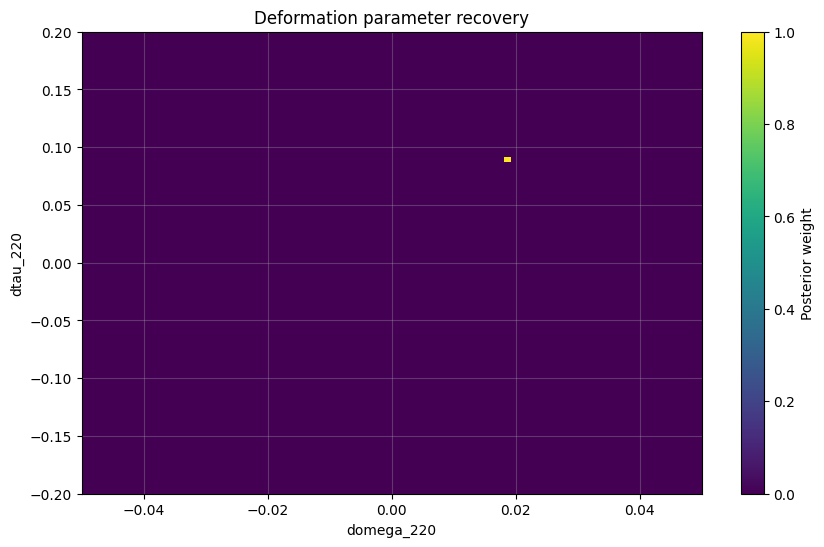

Recovered parameters
domega = 0.018750000000000003
dtau   = 0.08999999999999997


In [1]:
# ============================================================
# Notebook 4: Parameter estimation on deformation grid
# Block 1
#
# What this block does:
# - imports
# - Kerr remnant model
# - qnm backend
# - GR + MG waveform builders
# ============================================================

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import qnm


G = 6.67430e-11
C = 299_792_458.0
MSUN = 1.988409870698051e30

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


@dataclass
class KerrRemnant:
    mass_msun: float
    chi: float

    @property
    def time_unit(self):
        return G * self.mass_msun * MSUN / C**3


def get_kerr_qnm(remnant, l, m, n, s=-2):
    mode_seq = qnm.modes_cache(s=s, l=l, m=m, n=n)
    omega = mode_seq(a=remnant.chi)[0]

    wr = np.real(omega)
    wi = -np.imag(omega)

    Msec = remnant.time_unit
    wr_si = wr / Msec
    wi_si = wi / Msec

    return wr_si, wi_si


@dataclass
class RingdownMode:
    l: int
    m: int
    n: int
    amp: float
    phase: float


@dataclass
class ModeDeviation:
    domega: float = 0.0
    dtau: float = 0.0


def build_signal(remnant, modes, duration, fs, t0, deviations=None):
    t = np.arange(0, duration, 1/fs)
    h = np.zeros_like(t, dtype=np.complex128)

    for md in modes:
        wr, wi = get_kerr_qnm(remnant, md.l, md.m, md.n)

        if deviations and (md.l, md.m, md.n) in deviations:
            d = deviations[(md.l, md.m, md.n)]
            wr = wr * (1 + d.domega)
            wi = wi / (1 + d.dtau)

        dt = t - t0
        mask = dt >= 0

        comp = np.zeros_like(t, dtype=np.complex128)
        comp[mask] = md.amp * np.exp(-wi * dt[mask]) * np.exp(-1j * (wr * dt[mask] + md.phase))

        h += comp

    return t, h

# ============================================================
# Block 2
#
# What this block does:
# - synthetic noise
# - PSD model
# - frequency-domain inner product
# - Gaussian likelihood
# ============================================================

def add_noise(h, sigma=0.03, seed=1):
    rng = np.random.default_rng(seed)
    return h.real + rng.normal(0, sigma, len(h))


def analytic_psd(freqs):
    f0 = 250
    floor = 1e-46
    f = np.maximum(freqs,1)
    return floor * ((f0/f)**4 + 1 + (f/(2.5*f0))**2)


def fd_inner(a, b, dt, psd):
    af = np.fft.rfft(a)
    bf = np.fft.rfft(b)
    df = np.fft.rfftfreq(len(a), dt)[1]
    return 4*np.real(np.sum(af*np.conjugate(bf)/psd)*df)


def log_likelihood(template, data, dt, psd):
    resid = data - template
    return -0.5 * fd_inner(resid, resid, dt, psd)

# ============================================================
# Block 3
#
# What this block does:
# - build GR signal
# - build MG injected signal
# - generate noisy data
# - compute likelihood grid
# ============================================================

remnant = KerrRemnant(60,0.7)

modes = [
    RingdownMode(2,2,0,1,0),
    RingdownMode(2,2,1,.45,.3),
    RingdownMode(3,3,0,.25,-.5)
]

duration = .05
fs = 8192
t0 = .002

# TRUE deformation (choose zero for GR injection)
true_dev = {(2,2,0): ModeDeviation(.02,.1)}

t, h_true = build_signal(remnant, modes, duration, fs, t0, true_dev)

data = add_noise(h_true)

dt = 1/fs
freqs = np.fft.rfftfreq(len(t), dt)
psd = analytic_psd(freqs)

domega_grid = np.linspace(-.05,.05,81)
dtau_grid = np.linspace(-.2,.2,81)

LL = np.zeros((len(dtau_grid), len(domega_grid)))

for i,dtau in enumerate(dtau_grid):
    for j,domega in enumerate(domega_grid):

        dev = {(2,2,0): ModeDeviation(domega,dtau)}

        _, h_trial = build_signal(remnant, modes, duration, fs, t0, dev)

        LL[i,j] = log_likelihood(h_trial.real, data, dt, psd)

# ============================================================
# Block 4
#
# What this block does:
# - convert likelihood to posterior-like weights
# - plot heatmap
# - recover best-fit deformation
# ============================================================

LL -= np.max(LL)

posterior = np.exp(LL)

plt.figure()
plt.imshow(
    posterior,
    origin="lower",
    extent=[domega_grid[0], domega_grid[-1], dtau_grid[0], dtau_grid[-1]],
    aspect="auto"
)
plt.colorbar(label="Posterior weight")
plt.xlabel("domega_220")
plt.ylabel("dtau_220")
plt.title("Deformation parameter recovery")
plt.show()

best = np.unravel_index(np.argmax(posterior), posterior.shape)

best_dtau = dtau_grid[best[0]]
best_domega = domega_grid[best[1]]

print("Recovered parameters")
print("domega =", best_domega)
print("dtau   =", best_dtau)